**Name:** Micah Cermele

**Dataset:** Titanic - Machine Learning from Disaster

**Project Description:** 

This project builds a reproducible data workflow to explore passenger survival factors. I will clean the data, analyze key demographics, and visualize the results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the file (ensure the name matches your CSV exactly)
df = pd.read_csv("titanic.csv")

# Show the first 5 rows so we can see what the data looks like
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
def handle_missing_data(df):
    """
    Addresses missing values in the dataset:
    - Fills missing 'Age' values with the median.
    - Fills missing 'Embarked' values with the most common port.
    """
    # Fill missing Age with the middle value (median) so we don't skew results with outliers
    df['Age'] = df['Age'].fillna(df['Age'].median())
    
    # Fill missing Embarked with 'S' (Southampton), the most frequent port
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    
    return df

def drop_unreliable_columns(df):
    """
    Removes columns that are either mostly empty or don't provide 
    useful patterns for general analysis.
    """
    # 'Cabin' is mostly empty. 'Ticket' and 'Name' are unique text strings.
    df = df.drop(columns=['Cabin', 'Ticket', 'Name'])
    
    return df

# Now we actually use the functions we just created
df = handle_missing_data(df)
df = drop_unreliable_columns(df)

# Run this to verify that all columns now have 891 non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    str    
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(2)
memory usage: 62.8 KB


In [4]:
def survival_by_class(df):
    """
    Calculates the percentage of survivors based on their ticket class.
    """
    # Group by Pclass and find the mean of the Survived column
    analysis = df.groupby('Pclass')['Survived'].mean() * 100
    print("Survival Percentage by Class:")
    print(analysis)
    return analysis

# Run the function
survival_by_class(df)

Survival Percentage by Class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

C:\Users\micah.cermele\AppData\Local\Temp\ipykernel_26644\3280498586.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='viridis')


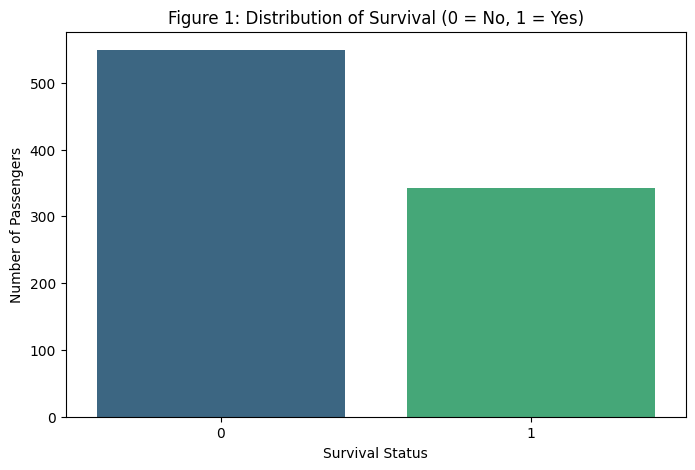

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', data=df, palette='viridis')

# Required labels and title
plt.title('Figure 1: Distribution of Survival (0 = No, 1 = Yes)')
plt.xlabel('Survival Status')
plt.ylabel('Number of Passengers')
plt.show()

**Figure 1** shows that more people perished than survived, which is a key baseline for any future model

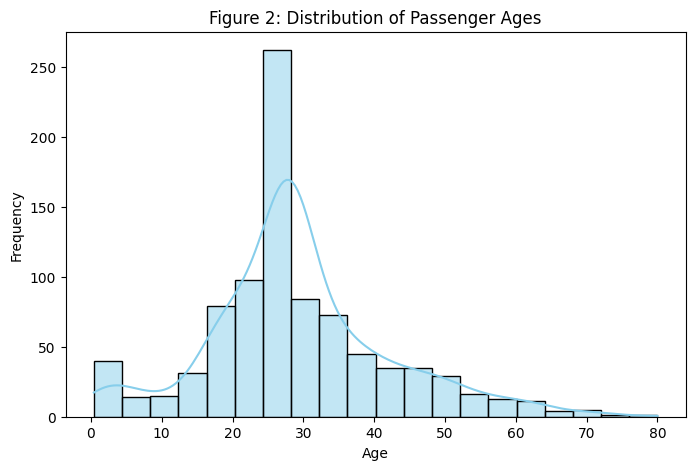

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')

# Required labels and title
plt.title('Figure 2: Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

**Figure 2** shows a peak in the 20–30 age range, which we filled using the median during our cleaning step

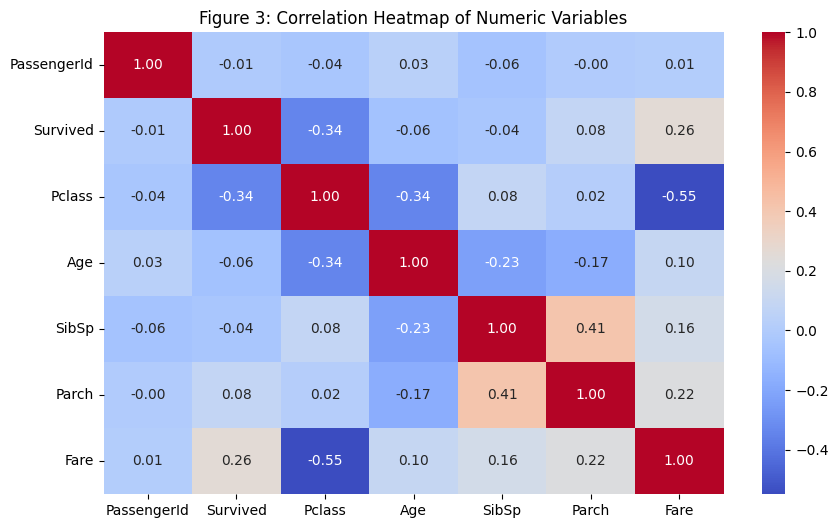

In [7]:
plt.figure(figsize=(10, 6))
# We only calculate correlation for numeric columns
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

# Required labels and title
plt.title('Figure 3: Correlation Heatmap of Numeric Variables')
plt.show()

**Figure 3** helps us see if certain features, like "Fare," are strongly linked to "Survival".

**Summary and Interpretation**

Through this analysis of the Titanic dataset, I observed that passenger class was a significant factor in survival; the exploratory analysis showed that first-class passengers had a much higher survival rate compared to third-class passengers. The age distribution indicated a peak among young adults, though this was influenced by my decision to fill missing values with the median age of approximately 28.

**Limitations and Assumptions:**

A major limitation of this dataset is the missing information in the 'Cabin' column, which I chose to drop because over 75% of the data was unavailable. I assumed that filling missing 'Age' values with the median was an appropriate way to maintain the dataset size without introducing extreme outliers. One surprising observation was the survival rate of children across different classes, which could be explored further in future machine learning projects